# N6 · Channel-Differential Fair Value — the live Consumer Duty risk

**Panel questions** — asked by the **CRO/CCO** (Consumer Duty champion):
1. *"Click-and-collect undercuts branch walk-up by 2–3%. The network is
   complaining. Resolve it."*
2. *"A regulator asks you to evidence fair value for airport pricing. What
   analysis do you produce?"*

The FCA's words drive the design (Price & Value Outcome update, Sept 2024):
**"group averages could disguise outliers or pockets of poor value"**, and
firms that *"only examined their products against a favourable subset of the
market were less effective."* So: distributions not averages, the full market
not a flattering subset, and the vulnerable-customer cross-tab front and centre.

**Contract:** simulate self-selection (age ↔ digital ↔ vulnerability
correlated) → the *within-channel* check finds nothing → the *mix/distribution*
check finds the harm → absolute benchmarking → airport as a distinct target
market → remediation + limitations.

In [1]:
# %matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from _style import C, apply_style
apply_style()
rng = np.random.default_rng(21)

# --- Cash travel-money customers: channel is CHOSEN, not assigned ------------
N = 30_000
age = np.clip(rng.normal(48, 17, N), 18, 90)
digital = 1 / (1 + np.exp((age - 52) / 11)) + rng.normal(0, 0.14, N)  # affinity
digital = np.clip(digital, 0, 1)
vulnerable = rng.random(N) < (0.06 + 0.12 * (age > 70) + 0.10 * (digital < 0.3))

# channel self-selection; vulnerable customers rely far more on assisted,
# in-person transactions regardless of stated digital affinity
p_online = np.clip(0.10 + 0.90 * digital, 0.02, 0.95)
p_online = np.where(vulnerable, p_online * 0.30, p_online)
online = rng.random(N) < p_online
airport = (~online) & (rng.random(N) < 0.06)          # last-minute walk-ups
channel = np.where(online, "online_c&c", np.where(airport, "airport", "branch_walkup"))

# realised total price as % of transaction (directional market levels)
PRICE = {"online_c&c": 2.7, "branch_walkup": 5.2, "airport": 10.5}
price = pd.Series(channel).map(PRICE).to_numpy() + rng.normal(0, 0.15, N)

df = pd.DataFrame({"age": age, "digital": digital, "vulnerable": vulnerable,
                   "channel": channel, "price_pct": price})
print(df.channel.value_counts().to_string())
print(f"\nVulnerable share overall: {vulnerable.mean():.0%}")

channel
online_c&c       17084
branch_walkup    12140
airport            776

Vulnerable share overall: 9%


## 1. The check that finds nothing (and why firms stop there)

Within each channel, vulnerable and standard customers pay the *same* rate —
the price sheet is channel-based, not customer-based. A within-channel
fairness check therefore passes. **This is the trap.**

In [2]:
within = df.groupby(["channel", "vulnerable"]).price_pct.mean().unstack()
within.columns = ["standard", "vulnerable"]
within["gap_pp"] = within.vulnerable - within.standard
print(within.round(2).to_string())
print("\nWithin-channel gaps ~0. A compliance pack that stops here signs off "
      "a product with a real fairness problem. Keep going.")

               standard  vulnerable  gap_pp
channel                                    
airport            10.5       10.50    0.00
branch_walkup       5.2        5.20    0.00
online_c&c          2.7        2.71    0.01

Within-channel gaps ~0. A compliance pack that stops here signs off a product with a real fairness problem. Keep going.


## 2. The check that finds the harm: mix and distribution

Vulnerable customers are *less digital*, so they self-select into the
expensive channels. The harm lives in the **channel mix**, and it only shows
up when you look at the distribution of realised prices by group.

Channel mix by group:
channel     airport  branch_walkup  online_c&c
vulnerable                                    
False           2.3           36.5        61.1
True            5.4           79.9        14.8

Effective average price:  standard 3.79%  vs vulnerable 5.12%   -> +1.33pp premium, pure mix
Share paying >5% of transaction:  standard 36%  vs vulnerable 78%


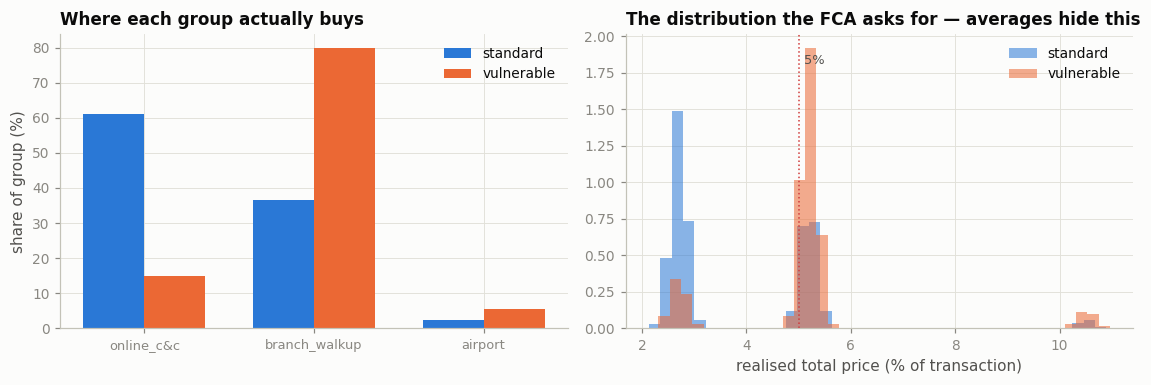

In [3]:
mix = df.groupby(["vulnerable", "channel"]).size().unstack()
mix = (mix.T / mix.sum(axis=1)).T
overall = df.groupby("vulnerable").price_pct.mean()
gap = overall[True] - overall[False]
share_over5 = df.groupby("vulnerable").price_pct.apply(lambda s: (s > 5).mean())

print("Channel mix by group:")
print((mix * 100).round(1).to_string())
print(f"\nEffective average price:  standard {overall[False]:.2f}%  "
      f"vs vulnerable {overall[True]:.2f}%   -> +{gap:.2f}pp premium, pure mix")
print(f"Share paying >5% of transaction:  standard {share_over5[False]:.0%}  "
      f"vs vulnerable {share_over5[True]:.0%}")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))
chs = ["online_c&c", "branch_walkup", "airport"]
x = np.arange(len(chs)); w = 0.36
for i, (grp, lab, col) in enumerate([(False, "standard", C["blue"]),
                                     (True, "vulnerable", C["orange"])]):
    axes[0].bar(x + (i - 0.5) * w, [mix.loc[grp, c] * 100 for c in chs], w,
                color=col, label=lab)
axes[0].set_xticks(x); axes[0].set_xticklabels(chs, fontsize=8.5)
axes[0].set_ylabel("share of group (%)")
axes[0].set_title("Where each group actually buys")
axes[0].legend()

for grp, lab, col in [(False, "standard", C["blue"]), (True, "vulnerable", C["orange"])]:
    axes[1].hist(df[df.vulnerable == grp].price_pct, bins=40, density=True,
                 alpha=0.55, color=col, label=lab)
axes[1].axvline(5, color=C["critical"], lw=1, ls=":")
axes[1].text(5.1, axes[1].get_ylim()[1] * 0.9, "5%", fontsize=8.5, color=C["ink2"])
axes[1].set_xlabel("realised total price (% of transaction)")
axes[1].set_title("The distribution the FCA asks for — averages hide this")
axes[1].legend()
plt.tight_layout(); plt.show()

## 3. Tie into the card portfolio — the repo's own fair-value engine

The prepaid-card side of the same story, straight from `fair_value.py`
(PRIN 2A.4 assessment: total lifecycle price vs benefit, differential
outcomes, remediation).

In [4]:
from travel_money_simulator import generate_card_portfolio
from fair_value import vulnerable_harm, fair_value_scorecard, identify_remediation

portfolio = generate_card_portfolio(20_000)
vh = vulnerable_harm(portfolio)
print(f"Card portfolio: vulnerable pay {vh['vulnerable_cost_pct']:.1%} of load "
      f"vs {vh['standard_cost_pct']:.1%} standard "
      f"(+{(vh['vulnerable_cost_pct'] - vh['standard_cost_pct'])*100:.1f}pp) "
      f"for LOWER benefit.")
print("\nWorst segments to remediate first (Red on price-to-value):")
print(identify_remediation(portfolio)[["channel", "group", "cards",
                                       "price_to_value"]].round(2).to_string(index=False))

Card portfolio: vulnerable pay 7.0% of load vs 5.3% standard (+1.7pp) for LOWER benefit.

Worst segments to remediate first (Red on price-to-value):
    channel      group  cards  price_to_value
post_office vulnerable    725            0.14
     retail vulnerable    623            0.13
     agency vulnerable    268            0.14


## 4. Absolute value, not a favourable subset

Benchmark two ways. Against the "high street" subset we look fine — exactly
the practice the FCA called out. Against the **full market** including the
fintechs, the walk-up and airport channels need a value story, not a
price story.

In [5]:
market = pd.DataFrame({
    "provider": ["Wise (explicit fee)", "Revolut (weekday)", "Our online C&C",
                 "Supermarket bureau", "High-street bank", "Our branch walk-up",
                 "Our airport", "Airport competitor"],
    "total_price_pct": [0.55, 0.50, 2.7, 3.8, 4.5, 5.2, 10.5, 11.5],
})
fav = market[market.provider.isin(["Supermarket bureau", "High-street bank",
                                   "Our branch walk-up", "Our online C&C"])]
print("vs favourable subset (high street only): our walk-up ranks "
      f"{(fav.total_price_pct < 5.2).sum() + 1} of {len(fav)} -> 'competitive'")
full_rank = (market.total_price_pct < 5.2).sum() + 1
print(f"vs FULL market: our walk-up ranks {full_rank} of {len(market)} -> "
      "the fintech comparison has to be answered with BENEFITS "
      "(cash in hand today, no app needed, FCA-authorised, buyback), not ignored.")

vs favourable subset (high street only): our walk-up ranks 4 of 4 -> 'competitive'
vs FULL market: our walk-up ranks 6 of 8 -> the fintech comparison has to be answered with BENEFITS (cash in hand today, no app needed, FCA-authorised, buyback), not ignored.


## 5. Airport: a distinct target market, or indefensible?

The airport customer is a *different target market*: last-minute, captive,
time-poor. Fair value must be argued on **total price vs total benefits for
that market**, with cost-to-serve (concession rent + **Minimum Annual
Guarantee**) as a *relevant — not sole —* factor (FCA FG22/5).

In [6]:
airport_econ = pd.DataFrame({
    "line": ["revenue_pct_of_load", "concession_rent_+_MAG", "staff_+_cash_logistics",
             "net_margin_pct_of_load"],
    "value_pct": [10.5, 5.8, 2.9, 10.5 - 5.8 - 2.9],
})
print(airport_econ.to_string(index=False))
print(f"\nNet airport margin ≈ {10.5 - 5.8 - 2.9:.1f}% of load — high price, "
      "moderate margin: cost-to-serve explains PART of the premium.")
print("Evidence pack: distinct target market definition; benefits (immediacy, "
      "availability, no pre-order); the MAG cost stack above; distribution of "
      "outcomes incl. vulnerable share at the airport; remediation (signpost "
      "'order online, collect airside' at a better rate); stated limitations.")

vul_air = df[df.channel == "airport"].vulnerable.mean()
print(f"\nVulnerable share at airport: {vul_air:.0%} vs {vulnerable.mean():.0%} "
      "overall — monitor: captivity + vulnerability is the toxic combination.")

                  line  value_pct
   revenue_pct_of_load       10.5
 concession_rent_+_MAG        5.8
staff_+_cash_logistics        2.9
net_margin_pct_of_load        1.8

Net airport margin ≈ 1.8% of load — high price, moderate margin: cost-to-serve explains PART of the premium.
Evidence pack: distinct target market definition; benefits (immediacy, availability, no pre-order); the MAG cost stack above; distribution of outcomes incl. vulnerable share at the airport; remediation (signpost 'order online, collect airside' at a better rate); stated limitations.

Vulnerable share at airport: 19% vs 9% overall — monitor: captivity + vulnerability is the toxic combination.


## 6. Resolving the network conflict (the Head of Product's half)

* The differential is **economically justified in part** — online is cheaper
  to serve and comparison-shopped — but the *fairness* screen above decides
  how wide it may stay, not the economics alone.
* Reframe click-&-collect as **branch footfall**: the order is collected (and
  cross-sold) in branch. Credit collections to branch scorecards, align
  Postmaster incentives to collections, and narrow the gap where the
  vulnerable-mix evidence demands it.
* Sequence: socialise with regional sales support managers **before** any
  public change — blindsided networks discount it away.

## The 60-second answer

> "Some channel differential is economically justified — online is cheaper to
> serve and comparison-shopped. But the check that matters isn't the one most
> packs run. Within each channel, vulnerable and standard customers pay the
> same rate, so a within-channel fairness check passes. The harm is in the
> **mix**: vulnerable customers are less digital and rely on assisted
> in-person service, they self-select into walk-up and airport, and in this
> analysis they pay over a point more for the same product — roughly a
> thirty percent premium — with four in five of them above the 5% line
> versus about a third of standard customers. That's exactly the 'pocket of
> poor value' the FCA says group averages disguise, and it's a cross-subsidy
> question under PRIN 2A.
>
> So I'd do three things: benchmark against the full market including Wise
> and Revolut and answer the gap with benefits, not silence; treat the
> airport as a distinct target market with the MAG cost stack as a relevant
> but not sole factor; and resolve the network complaint by crediting
> click-and-collect to branch scorecards while narrowing the differential
> where the vulnerable-mix evidence demands it — socialised with the regional
> managers before anything changes publicly."

### What I'd say if pushed deeper

1. **"Is self-selection actually a fairness problem if customers choose?"** —
   Choice mitigates but doesn't absolve: the Duty asks about *outcomes*, and
   'less-digital' is not a free choice for many vulnerable customers. The
   remediation isn't forcing them online — it's signposting, assisted
   ordering in branch at the online rate, and capping the differential.
2. **"What would make you comfortable keeping the airport premium?"** — A
   documented distinct-target-market assessment, the cost stack, benefits
   evidence, a low and monitored vulnerable share, and a cheaper substitute
   actively signposted (order-ahead airside collection). If the vulnerable
   share at the airport rises, the assessment fails and price must move.
3. **Honest limitation.** The vulnerability flag here is binary and simulated;
   real flags are under-recorded and correlated with exactly the channels
   where recording is weakest (branch cash). I'd triangulate with complaints
   data, assisted-transaction rates and age proxies before certifying the
   assessment — and say in the document what the flag cannot see.